# RoBerta Text Classification Model

This notebook trains a DistilBERT model on the preprocessed text data with an 80-10-10 train-validation-test split.

## Section 1: Load and Prepare Data

Load the preprocessed data and verify that the 'other_posts' and 'label' columns are ready for model training.

In [2]:
import subprocess
import sys
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [7]:

data = pd.read_csv('third_dataset.csv')
data= data.sample(frac=1, random_state=42).reset_index(drop=True)


print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nColumn names:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)
print("\nLabel distribution:")
print(data['label'].value_counts())

Dataset shape: (47311, 12)

First few rows:
   Unnamed: 0              author      subreddit  \
0         NaN           jepranshu     meditation   
1     13881.0           lucifurXx  healthanxiety   
2         NaN              w00dy2          jokes   
3         NaN  www_earthlings_com  relationships   
4      4610.0           mowmoomow   mentalhealth   

                                         report_post  \
0                                                NaN   
1  How can you tell whether you're actually sick ...   
2                                                NaN   
3                                                NaN   
4  how do i handle ptsd when my mom constantly do...   

                                         other_posts  is_self_report  \
0  The Universal Words: Identify Your Original Se...               0   
1  how can you tell whether you're actually sick ...               1   
2  Why is religion so against gay marriage? Becau...               0   
3  My [23 M] girlf

In [7]:
def minimal_preprocess(text):
    text = text.lower()
    #  Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove usernames (Twitter/Reddit style)
    text = re.sub(r'@\w+', '', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [4]:

data['other_posts']= data['other_posts'].apply(minimal_preprocess)

## Section 2: Split Data into Train, Validation, and Test Sets

Use scikit-learn's train_test_split to create 80% training, 10% validation, and 10% test sets.

In [14]:
# Split data into train (80%) and temp (20%)
train_data, temp_data = train_test_split(
    data, 
    test_size=0.2, 
    random_state=42, 
    stratify=data['label']
)

# Split temp (20%) into validation (50% of 20% = 10%) and test (50% of 20% = 10%)
val_data, test_data = train_test_split(
    temp_data, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_data['label']
)

print(f"Training set size: {len(train_data)} ({len(train_data)/len(data)*100:.1f}%)")
print(f"Validation set size: {len(val_data)} ({len(val_data)/len(data)*100:.1f}%)")
print(f"Test set size: {len(test_data)} ({len(test_data)/len(data)*100:.1f}%)")

print("\nLabel distribution in each set:")
print("Training set:")
print(train_data['label'].value_counts())
print("\nValidation set:")
print(val_data['label'].value_counts())
print("\nTest set:")
print(test_data['label'].value_counts())

# Reset indices
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

Training set size: 37848 (80.0%)
Validation set size: 4731 (10.0%)
Test set size: 4732 (10.0%)

Label distribution in each set:
Training set:
label
0    19200
1    18648
Name: count, dtype: int64

Validation set:
label
0    2400
1    2331
Name: count, dtype: int64

Test set:
label
0    2400
1    2332
Name: count, dtype: int64


## Section 3: Tokenize Text with DistilBERT

Use DistilBertTokenizer to tokenize the 'other_posts' text data with appropriate padding and truncation.

In [8]:
# Initialize the RoBerta tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

# Define tokenization function
def tokenize_function(texts, max_length=512):
    """
    Tokenize texts using RoBerta tokenizer
    """
    encodings = tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return encodings


In [15]:
# Tokenize train, validation, and test sets
print("Tokenizing training data...")
train_encodings = tokenize_function(train_data['other_posts'])

print("Tokenizing validation data...")
val_encodings = tokenize_function(val_data['other_posts'])

print("Tokenizing test data...")
test_encodings = tokenize_function(test_data['other_posts'])

print("\nTokenization complete!")
print(f"Train encodings shape: input_ids={train_encodings['input_ids'].shape}")
print(f"Validation encodings shape: input_ids={val_encodings['input_ids'].shape}")
print(f"Test encodings shape: input_ids={test_encodings['input_ids'].shape}")

Tokenizing training data...
Tokenizing validation data...
Tokenizing test data...

Tokenization complete!
Train encodings shape: input_ids=torch.Size([37848, 512])
Validation encodings shape: input_ids=torch.Size([4731, 512])
Test encodings shape: input_ids=torch.Size([4732, 512])


## Section 4: Create PyTorch Datasets

Create custom PyTorch Dataset classes for train, validation, and test sets with tokenized inputs and labels.

In [9]:
class TextClassificationDataset(Dataset):
    """
    Custom PyTorch Dataset for text classification with tokenized inputs
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


In [16]:

# Create datasets
train_dataset = TextClassificationDataset(train_encodings, train_data['label'])
val_dataset = TextClassificationDataset(val_encodings, val_data['label'])
test_dataset = TextClassificationDataset(test_encodings, test_data['label'])

print("Dataset Creation Complete!")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Create data loaders
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaders created with batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Dataset Creation Complete!
Train dataset size: 37848
Validation dataset size: 4731
Test dataset size: 4732

Data loaders created with batch size: 4
Training batches: 9462
Validation batches: 1183
Test batches: 1183


## Section 5: Initialize RoBerta Model

Load a pretrained DistilBERT model for sequence classification and configure training parameters.

In [8]:
# Determine number of labels
num_labels = len(data['label'].unique())
print(f"Number of unique labels: {num_labels}")

# Load pretrained DistilBERT model for sequence classification
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Number of unique labels: 2
Using device: cuda


In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=num_labels
)

# Move model to device
model.to(device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [10]:


def seed_everything(seed=42):
    np.random.seed(seed)               # NumPy RNG
    torch.manual_seed(seed)            # CPU
    torch.cuda.manual_seed(seed)       # Current GPU
    torch.cuda.manual_seed_all(seed)   # All GPUs (if you have more than 1)
    
    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [17]:

# Define optimizer and learning rate scheduler
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * 3  # 3 epochs
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

print("\nModel Configuration:")
print(f"Model: RoBerta for Sequence Classification")
print(f"Number of labels: {num_labels}")
print(f"Total training steps: {total_steps}")
print(f"Learning rate: 2e-5")
print(f"Device: {device}")


Model Configuration:
Model: RoBerta for Sequence Classification
Number of labels: 2
Total training steps: 28386
Learning rate: 2e-5
Device: cuda


## Section 6: Train the Model

Train the DistilBERT model on the training set using a training loop, with validation on the validation set after each epoch.

In [ ]:
def train_epoch(model, train_loader, optimizer, scheduler, device):
    """
    Train the model for one epoch
    """
    model.train()
    total_loss = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss


In [39]:
def evaluate(model, eval_loader, device, threshold=0.5):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')

            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            p1 = probs[:, 1]                     # class-1 probability

            predictions.extend(p1.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    # 🔴 THRESHOLD ONCE — HERE
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    binary_preds = (predictions >= threshold).astype(int)

    avg_loss = total_loss / len(eval_loader)
    accuracy = accuracy_score(true_labels, binary_preds)

    return avg_loss, accuracy, predictions, true_labels


In [15]:
import torch
torch.cuda.empty_cache()


In [16]:

# Training parameters
num_epochs = 3
best_val_accuracy = 0
patience = 1
patience_counter = 0

print("Starting model training...\n")

# Training loop
for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"{'='*50}")
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"Training Loss: {train_loss:.4f}")
    
    # Validate
    val_loss, val_accuracy, _, _ = evaluate(model, val_loader, device)
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    
    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_roberta_model_v1.pt')
        print("Best model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

print("\nTraining completed!")

Starting model training...


Epoch 1/3


Training: 100%|██████████| 9462/9462 [52:24<00:00,  3.01it/s]


Training Loss: 0.1994


Evaluating: 100%|██████████| 1183/1183 [01:54<00:00, 10.32it/s]


Validation Loss: 0.1494
Validation Accuracy: 0.9463
Best model saved!

Epoch 2/3


...

Validation Loss: 0.1267
Validation Accuracy: 0.9552
Best model saved!

Epoch 3/3


Training: 100%|██████████| 9462/9462 [52:03<00:00,  3.03it/s]


Training Loss: 0.1130


Evaluating: 100%|██████████| 1183/1183 [01:46<00:00, 11.15it/s]

Validation Loss: 0.1784
Validation Accuracy: 0.9484
Early stopping triggered after 3 epochs

Training completed!


## Section 7: Evaluate on Validation and Test Sets

Evaluate model performance on both validation and test sets using accuracy, precision, recall, and F1-score metrics.

In [17]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_model_v1.pt'))

print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

# Evaluate on validation set
print("\n--- Validation Set Evaluation ---")
val_loss, val_accuracy, val_predictions, val_true_labels = evaluate(model, val_loader, device)
val_precision = precision_score(val_true_labels, val_predictions, average='weighted')
val_recall = recall_score(val_true_labels, val_predictions, average='weighted')
val_f1 = f1_score(val_true_labels, val_predictions, average='weighted')

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")
print(f"Validation F1-Score: {val_f1:.4f}")

print("\nValidation Set Classification Report:")
print(classification_report(val_true_labels, val_predictions))

# Evaluate on test set
print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, test_loader, device)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Validation vs Test Performance")
print("="*60)
print(f"{'Metric':<15} {'Validation':<15} {'Test':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {val_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<15} {val_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<15} {val_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<15} {val_f1:<15.4f} {test_f1:<15.4f}")

FINAL MODEL EVALUATION

--- Validation Set Evaluation ---


Evaluating: 100%|██████████| 1183/1183 [01:46<00:00, 11.15it/s]


Validation Loss: 0.1267
Validation Accuracy: 0.9552
Validation Precision: 0.9562
Validation Recall: 0.9552
Validation F1-Score: 0.9551

Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2400
           1       0.98      0.93      0.95      2331

    accuracy                           0.96      4731
   macro avg       0.96      0.95      0.96      4731
weighted avg       0.96      0.96      0.96      4731


--- Test Set Evaluation ---


Evaluating: 100%|██████████| 1183/1183 [01:46<00:00, 11.10it/s]

Test Loss: 0.1441
Test Accuracy: 0.9510
Test Precision: 0.9522
Test Recall: 0.9510
Test F1-Score: 0.9509

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2400
           1       0.98      0.92      0.95      2332

    accuracy                           0.95      4732
   macro avg       0.95      0.95      0.95      4732
weighted avg       0.95      0.95      0.95      4732


SUMMARY: Validation vs Test Performance
Metric          Validation      Test           
------------------------------------------------------------
Accuracy        0.9552          0.9510         
Precision       0.9562          0.9522         
Recall          0.9552          0.9510         
F1-Score        0.9551          0.9509         


In [18]:
# Tokenize the input text
input_text ="Having Grandma be your daycare can be awesome, but it can also suck.\
Can I just vent really quickly My MIL lives with us &amp; helps with child care. \
She basically functions as a live-in nanny.  \
She’s a sweet woman. But man, can she annoy me. She says things like “[toddler’s name] doesn’t do that when he’s with ME.” \
She sometimes calls him “my king,” I once heard her call him The King of Kings.  \
She calls my baby girl “my queen” &amp; also “mi reina” in Spanish. \
They’re too young for it to be a joke, it just feels a bit much to me. \
She constantly refers to them as “my babies” &amp; “my kids.”\
She constantly calls them to come to her to get them away from me &amp; says “Mommy’s busy” but I have to tell her it’s ok, they’re fine. \
She will keep trying to interact with them even if they’re interacting with me, but by talking about something completely different than what we are doing.  \
Again, she’s a sweet woman, &amp; we have some cultural differences, &amp; they are the most important things in her life, but sometimes I just want to be mommy without her around. \
And I feel selfish but I want to be more important to my kids than Grandma.My husband at least recognizes that she’s not perfect, \
she’s not the sharpest tool in the shed.  But he will do anything to not hurt her feelings &amp; heap tons of praise on her.\
But he’s comfortable being stern with me at times or lets me know he’s disappointed in something I’ve done but wouldn’t dare do that to her.\
I’ll stop there.  As you see I have conflicting feelings about my MIL.\
I’m grateful for how she helps us but sometimes want her to just leave us alone, even move out &amp; \
find other child care.  If anyone wants to suggest to post this to r/justnomil, I actually stay away from that sub so I don’t fuel my anger lol,\
but I apologize if you feel it’s inappropriate to post this here. \
Thank you so much if you’ve read this. \
It’s so hard to have an aging parent come live with you.  Can anyone relate?"
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	predicted_class = torch.argmax(logits, dim=1).item()
print(logits)
print(f"Predicted class: {predicted_class}")

tensor([[ 1.5260, -1.4251]], device='cuda:0')
Predicted class: 0


****results summarty****
the model is outputing a great performence metrices on the current dataset but in real world domain it doesn't work that will

In [19]:


# Tokenize the input text
input_text ="Drinking alone I️ hate feeling this way. I’ve always been introverted but I’ve never felt this damn lonely."
input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	predicted_class = torch.argmax(logits, dim=1).item()
print(logits)
print(f"Predicted class: {predicted_class}")

tensor([[ 1.3887, -1.3342]], device='cuda:0')
Predicted class: 0


In [20]:
input_text= "I [21/M] am unsure if I should tell my friends about my health issues. I am currently doing a couple of research projects at university in the biology building as a post-grad. My lab mates, all of whom are at least 3 years older than me, and I all care about each other as friends; we hang out, joke around, and like to keep a friendly atmosphere. This usually leads to most of them noticing when something is wrong with someone by the look on their face, and this is especially the case with me on some days. I had a blood test done recently which showed that 40% of my hemoglobin is HbS, which is characteristic of Sickle Cell trait and another co-existing condition, which is unknown to me at the moment (I'm working with my doctor to figure it out). Sometimes I show up to the lab in the morning and am just tired all around; it has no effect on my productivity, but I just don't feel like socializing at the moment, and some of my friends get the feeling that I'm trying to brush them off. In reality, I'm just exhausted, physically and mentally.\
What I'm worried about, because of past experiences with acquaintances, is that if I tell them about my chronic issue, it's going to cause a great deal of worry and/or stress over me, and I don't wish that at all, since I'm going to be working in the lab for the next year, and some of my lab mates have to present at conferences in a couple of months. I'm the type of person to work through tiredness and exhaustion if it means I can get some valuable output/results,\
so I'm not worried about myself. Am I analyzing a bit too much, or is this something my adviser and lab mates need to know?\
tl;dr: Chronic blood issue causes fatigue for me almost everyday, and friends and lab mates are worried about me looking tired all the time. Should I tell them, or keep saying that I'm alright?"

input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	predicted_class = torch.argmax(logits, dim=1).item()
print(logits)
print(f"Predicted class: {predicted_class}")


tensor([[ 0.6029, -0.4586]], device='cuda:0')
Predicted class: 0


In [21]:
real_world_domain= pd.read_csv('non_mental_disorders_relevent_subreddits_control.csv')
real_world_domain=real_world_domain[20000:]
real_world_domain['label']=0
for idx , row in real_world_domain.iterrows():
    
    if pd.isna(row['other_posts']):
        real_world_domain.at[idx,'other_posts']=' '
real_world_domain['other_posts']=real_world_domain['other_posts'].apply(minimal_preprocess)
test_encodings = tokenize_function(real_world_domain['other_posts'])

real_world_domain_dataset = TextClassificationDataset(test_encodings, real_world_domain['label'])
real_world_domain_loader = DataLoader(real_world_domain_dataset, batch_size=batch_size, shuffle=False)




In [22]:

# Evaluate on test set
print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, real_world_domain_loader, device)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Validation vs Test Performance")
print("="*60)
print(f"{'Metric':<15} {'Validation':<15} {'Test':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {val_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<15} {val_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<15} {val_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<15} {val_f1:<15.4f} {test_f1:<15.4f}")


--- Test Set Evaluation ---


Evaluating: 100%|██████████| 20128/20128 [29:58<00:00, 11.19it/s]


Test Loss: 0.0764
Test Accuracy: 0.9821
Test Precision: 1.0000
Test Recall: 0.9821
Test F1-Score: 0.9910

Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     80511
           1       0.00      0.00      0.00         0

    accuracy                           0.98     80511
   macro avg       0.50      0.49      0.50     80511
weighted avg       1.00      0.98      0.99     80511


SUMMARY: Validation vs Test Performance
Metric          Validation      Test           
------------------------------------------------------------
Accuracy        0.9552          0.9821         
Precision       0.9562          1.0000         
Recall          0.9552          0.9821         
F1-Score        0.9551          0.9910         


In [23]:
test_data=pd.read_csv('test_data_5000.csv')
test_data['label'] = (test_data['group'] == "distress").astype(int)
test_data=test_data[['response','label']]

test_data['response']=test_data['response'].apply(minimal_preprocess)
test_encodings=tokenizer(test_data['response'].tolist(),return_tensors='pt',padding=True,max_length=128)
test_dataset=TextClassificationDataset(test_encodings,test_data['label'])
test_dataloader=DataLoader(test_dataset,batch_size=16,shuffle=False)

In [24]:
test_data.head()

,response,label
0,"i'm feeling fairly balanced, staying productiv...",0
1,"i'm feeling fairly stable, staying consistent,...",0
2,"i'm feeling fairly okay, staying productive, a...",0
3,"i'm feeling fairly good, staying productive, a...",0
4,"i've been feeling overwhelmed and unfocused, m...",1


In [25]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_model_v1.pt'))

print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, test_dataloader, device)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Validation vs Test Performance")
print("="*60)
print(f"{'Metric':<15} {'Test':<15}")
print("-"*60)
print(f"{'Accuracy':<15}{test_accuracy:<15.4f}")
print(f"{'Precision':<15}{test_precision:<15.4f}")
print(f"{'Recall':<15}{test_recall:<15.4f}")
print(f"{'F1-Score':<15}{test_f1:<15.4f}")



--- Test Set Evaluation ---


Evaluating: 100%|██████████| 313/313 [00:06<00:00, 46.29it/s]

Test Loss: 2.0680
Test Accuracy: 0.0982
Test Precision: 0.0972
Test Recall: 0.0982
Test F1-Score: 0.0977

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.06      0.06      2437
           1       0.13      0.13      0.13      2563

    accuracy                           0.10      5000
   macro avg       0.10      0.10      0.10      5000
weighted avg       0.10      0.10      0.10      5000


SUMMARY: Validation vs Test Performance
Metric          Test           
------------------------------------------------------------
Accuracy       0.0982         
Precision      0.0972         
Recall         0.0982         
F1-Score       0.0977         


In [19]:
mental_subr_control= pd.read_csv("mental_disorders_subreddits_control.csv")

In [25]:
mental_subr_control['other_posts'].info()
mental_subr_control['other_posts']=mental_subr_control['other_posts'].astype(str)

<class 'pandas.core.series.Series'>
RangeIndex: 97358 entries, 0 to 97357
Series name: other_posts
Non-Null Count  Dtype 
--------------  ----- 
97357 non-null  object
dtypes: object(1)
memory usage: 760.7+ KB


In [26]:
mental_subr_control['label']=1
mental_subr_control['other_posts']=mental_subr_control['other_posts'].apply(minimal_preprocess)
encodings =tokenize_function(mental_subr_control['other_posts'])
test_dataloader=DataLoader(TextClassificationDataset(encodings,mental_subr_control['label']),batch_size=batch_size,shuffle=True)

In [ ]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_model_v1.pt'))

# Evaluate on test     
print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, test_loader, device)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Validation vs Test Performance")
print("="*60)
print(f"{'Metric':<15} {'Validation':<15} {'Test':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {val_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<15} {val_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<15} {val_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<15} {val_f1:<15.4f} {test_f1:<15.4f}")

FINAL MODEL EVALUATION

--- Validation Set Evaluation ---


Evaluating: 100%|██████████| 24340/24340 [39:00<00:00, 10.40it/s] 


Validation Loss: 1.1243
Validation Accuracy: 0.5413
Validation Precision: 1.0000
Validation Recall: 0.5413
Validation F1-Score: 0.7024

Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.54      0.70     97358

    accuracy                           0.54     97358
   macro avg       0.50      0.27      0.35     97358
weighted avg       1.00      0.54      0.70     97358


--- Test Set Evaluation ---


Evaluating:  14%|█▍        | 168/1183 [00:15<01:34, 10.71it/s]


KeyboardInterrupt: 

In [ ]:
mental_subr= pd.read_csv("mental_disorders_subreddits_control.csv")
non_mental_subr= pd.read_csv('non_mental_disorders_relevent_subreddits_control.csv')


In [ ]:
mental_subr

(100511, 10)

In [17]:
mental_subr['label']=1
non_mental_subr['label']=0
combined_df=pd.concat([mental_subr,non_mental_subr],ignore_index=True)
combined_df=combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_df['other_posts']=combined_df['other_posts'].astype(str)
combined_df['other_posts']=combined_df['other_posts'].apply(minimal_preprocess)
encodings =tokenize_function(combined_df['other_posts'])
test_dataloader=DataLoader(TextClassificationDataset(encodings,combined_df['label']),batch_size=4,shuffle=True)

In [21]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_model_v1.pt'))

# Evaluate on test     
print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, test_dataloader, device)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Validation vs Test Performance")
print("="*60)
print(f"{'Metric':<15} {'Validation':<15} {'Test':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {val_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<15} {val_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<15} {val_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<15} {val_f1:<15.4f} {test_f1:<15.4f}")


--- Test Set Evaluation ---


Evaluating: 100%|██████████| 49468/49468 [1:18:10<00:00, 10.55it/s]


Test Loss: 0.5918
Test Accuracy: 0.7653
Test Precision: 0.8258
Test Recall: 0.7653
Test F1-Score: 0.7528

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.98      0.81    100511
           1       0.97      0.54      0.69     97358

    accuracy                           0.77    197869
   macro avg       0.83      0.76      0.75    197869
weighted avg       0.83      0.77      0.75    197869


SUMMARY: Validation vs Test Performance
Metric          Validation      Test           
------------------------------------------------------------


NameError: name 'val_accuracy' is not defined

In [59]:
input_text= "i have been having trouble sleeping , and concentrating for a while , and i've been lonely for a while now , i feel like i have no purpose in life  and i just want to sleep forever \
     i feel so empty and sad all the time  i dont know what to do anymore and it feels like im stuck in a dark hole, fucked up , tired of feeling like this and even my cloosest people don't get it  " 
 
input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	probs = torch.softmax(logits, dim=1)
	p1 = probs[:, 1]
	predicted_class = int(p1.item()>=0.1)
print(logits)
print(probs)
print(f"Predicted class: {predicted_class}")


tensor([[ 1.0693, -0.9784]], device='cuda:0')
tensor([[0.8857, 0.1143]], device='cuda:0')
Predicted class: 1


In [60]:
input_text= "I feel so empty inside. I don't know what to do anymore."
 
input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	probs = torch.softmax(logits, dim=1)
	p1 = probs[:, 1]
	predicted_class = int(p1.item()>=0.1)
print(logits)
print(probs)
print(f"Predicted class: {predicted_class}")


tensor([[ 1.5735, -1.3487]], device='cuda:0')
tensor([[0.9489, 0.0511]], device='cuda:0')
Predicted class: 0


In [ ]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_model_v1.pt'))

# Evaluate on test     
print("\n--- Test Set Evaluation ---")
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(model, test_dataloader, device,threshold=0.3)




--- Test Set Evaluation ---


Evaluating: 100%|██████████| 49468/49468 [1:17:57<00:00, 10.58it/s]


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [50]:
binary_preds = (test_predictions >= 0.3).astype(int)
test_precision = precision_score(test_true_labels, binary_preds, average='weighted')
test_recall = recall_score(test_true_labels, binary_preds, average='weighted')
test_f1 = f1_score(test_true_labels, binary_preds, average='weighted')

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(test_true_labels, binary_preds))


Test Loss: 0.5918
Test Accuracy: 0.8056
Test Precision: 0.8407
Test Recall: 0.8056
Test F1-Score: 0.7999

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.97      0.83    100511
           1       0.95      0.64      0.76     97358

    accuracy                           0.81    197869
   macro avg       0.84      0.80      0.80    197869
weighted avg       0.84      0.81      0.80    197869



In [ ]:
thres=[0.025,0.05,0.075,0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3]

for t in thres:
    print(f"\n--- Test Set Evaluation at Threshold: {t} ---")
    

    binary_preds = (test_predictions >= t).astype(int)
    test_precision = precision_score(test_true_labels, binary_preds, average='weighted')
    test_recall = recall_score(test_true_labels, binary_preds, average='weighted')
    test_f1 = f1_score(test_true_labels, binary_preds, average='weighted')

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")

    print("\nTest Set Classification Report:")
    print(classification_report(test_true_labels, binary_preds))


--- Test Set Evaluation at Threshold: 0.025 ---
Test Loss: 0.5918
Test Accuracy: 0.8056
Test Precision: 0.8281
Test Recall: 0.8044
Test F1-Score: 0.8013

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78    100511
           1       0.74      0.94      0.82     97358

    accuracy                           0.80    197869
   macro avg       0.83      0.81      0.80    197869
weighted avg       0.83      0.80      0.80    197869


--- Test Set Evaluation at Threshold: 0.05 ---
Test Loss: 0.5918
Test Accuracy: 0.8056
Test Precision: 0.8513
Test Recall: 0.8502
Test F1-Score: 0.8501

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85    100511
           1       0.83      0.88      0.85     97358

    accuracy                           0.85    197869
   macro avg       0.85      0.85      0.85    197869
weighted avg       0.85     

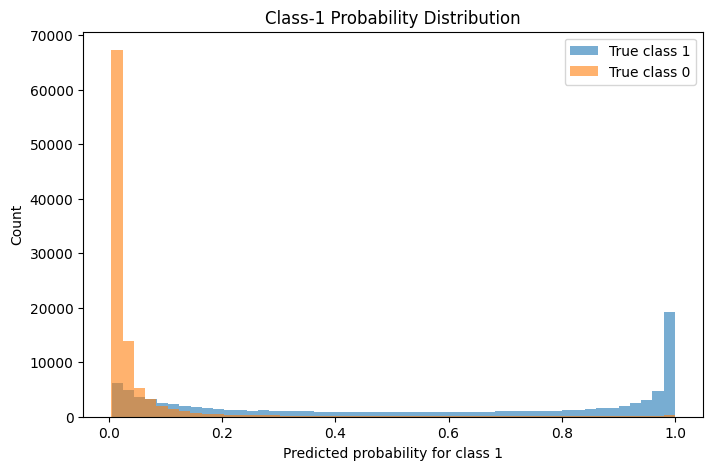

In [62]:
import numpy as np
import matplotlib.pyplot as plt
binary_preds = (test_predictions >= 0.1).astype(int)
# convert to numpy
preds = np.array(test_predictions)
labels = np.array(test_true_labels)

# split by true class
p_class1 = preds[labels == 1]   # true positives + false negatives
p_class0 = preds[labels == 0]   # true negatives + false positives

# plot
plt.figure(figsize=(8, 5))
plt.hist(p_class1, bins=50, alpha=0.6, label="True class 1")
plt.hist(p_class0, bins=50, alpha=0.6, label="True class 0")
plt.xlabel("Predicted probability for class 1")
plt.ylabel("Count")
plt.legend()
plt.title("Class-1 Probability Distribution")
plt.show()


## observations
* **using argmax to predict probabelities resulted to 0.54 recall on class 1 , the model produced so many False Negatives**
* **fine tuning threshold fixed much of the problem as the performence increases much at 0.05-0.1 treshold to have a 0.82-0.79 recall on class 1**
* **lower thresholds produce higher recall on class one , but hurts the overall performence reducing the accuracy by an observable ammount but it can still be used because False Negatives on class 1 is actually more critical than False Negatives on class 0**
* **all of this is justified on the probabelities histogram showing the distribution of the model probabilities in class 0 and 1**


## not done with this model yet 🔥🔥